In [85]:
import pandas as pd
import matplotlib.pyplot as plt

# Lire un fichier CSV et créer un DataFrame
df = pd.read_csv('activites_brutes.csv')

# Afficher les premières lignes
print(df.head())

# Afficher les informations du DataFrame
print(df.info())

   resource_state                                 athlete  \
0               2  {'id': 124945657, 'resource_state': 1}   
1               2  {'id': 124945657, 'resource_state': 1}   
2               2  {'id': 124945657, 'resource_state': 1}   
3               2  {'id': 124945657, 'resource_state': 1}   
4               2  {'id': 124945657, 'resource_state': 1}   

                      name  distance  moving_time  elapsed_time  \
0    Course à pied de nuit    7547.9         1822          1833   
1          10*400 moy 3:01    9561.0         2283          2496   
2          10*400 Moy 3:01   12299.0         2828          3084   
3    Course à pied de nuit   16425.0         3717          3881   
4  Course à pied en soirée    8721.5         2130          2425   

   total_elevation_gain type sport_type  workout_type  ... elev_high  \
0                  73.0  Run        Run           NaN  ...     102.0   
1                  13.0  Run        Run           NaN  ...     112.0   
2             

## Analyse globale des éléments 


In [86]:
nb_colonnes = df.shape[1]
nb_lignes = df.shape[0]
print(f"Nombre de colonnes : {nb_colonnes}")
print(f"Nombre de lignes : {nb_lignes}") # on affiche le nombre de lignes celle-ci sont au nombre de 200. L'extraction entraine une 
# Une perte d'information. 
# Création d'un petit tableau récapitulatif
types_colonnes = pd.DataFrame({
    'Type': df.dtypes,
    'Valeurs non-nulles': df.count(),
    'Exemple': df.iloc[0] if len(df) > 0 else "N/A"
})

print(types_colonnes)

Nombre de colonnes : 57
Nombre de lignes : 571
                                  Type  Valeurs non-nulles  \
resource_state                   int64                 571   
athlete                            str                 571   
name                               str                 571   
distance                       float64                 571   
moving_time                      int64                 571   
elapsed_time                     int64                 571   
total_elevation_gain           float64                 571   
type                               str                 571   
sport_type                         str                 571   
workout_type                   float64                  98   
device_name                        str                 571   
id                               int64                 571   
start_date                         str                 571   
start_date_local                   str                 571   
timezone               

Suppression des colonnes unutile 

## Netoyage des données 

In [87]:
# 1. Ta sélection de colonnes (Zone Silver)
colonnes_souhaitees = [
    'start_date_local', 'name', 'type', 'distance', 'moving_time', 
    'total_elevation_gain', 'average_speed', 'max_speed', 
    'average_heartrate', 'max_heartrate', 'suffer_score', 
    'location_city', 'average_cadence', 'average_temp', 'kilojoules'
]

# 2. Filtrage intelligent des activités (Run uniquement)
# Liste des types officiels Strava pour la course
types_run_officiels = ['Run', 'TrailRun', 'VirtualRun']

# Liste de mots-clés pour identifier la course dans le nom (au cas où)
mots_cles_run = ['run', 'course', 'trail', '400', 'séance', 'entraînement']

# On filtre : soit le type est 'Run', soit le nom contient un mot-clé de course
# (en ignorant les majuscules avec .str.lower())
masque_run = (df['type'].isin(types_run_officiels)) | \
             (df['name'].str.lower().str.contains('|'.join(mots_cles_run), na=False))

# On exclut spécifiquement le vélo et la muscu même s'ils ont un mot-clé
masque_exclure = df['name'].str.lower().str.contains('vélo|musculation|poids|randonnée|marche', na=False)

df_propre = df[masque_run & ~masque_exclure].copy()

# 3. Application de ta sélection de colonnes
colonnes_finales = [c for c in colonnes_souhaitees if c in df_propre.columns]
df_propre = df_propre[colonnes_finales]



In [88]:
print(df_propre[['name']].drop_duplicates())

                                 name
0               Course à pied de nuit
1                     10*400 moy 3:01
2                     10*400 Moy 3:01
4             Course à pied en soirée
8     Course à pied dans l'après-midi
9          Bla-bla run avec les girls
14             Course à pied le matin
17                         Pas facile
36    Pause au involontaire au milieu
74             Course à pied matinale
85   Course à pied le matin avec lulu
109            Entraînement en soirée
112             Course à pied le midi
187                         Montre hs
258                    Trail le matin
314           Trail dans l'après-midi
336             Course à pied du midi
473                     Trail le midi


Converstion des valeurs : 

In [89]:
print(df_propre[['distance','moving_time']])


     distance  moving_time
0      7547.9         1822
1      9561.0         2283
2     12299.0         2828
3     16425.0         3717
4      8721.5         2130
..        ...          ...
565    4994.0         1613
566       6.0            8
567   10000.0         2274
569    4995.0         1013
570       8.0            5

[484 rows x 2 columns]


In [90]:
# Conversion de la distance (m -> km)
if 'distance' in df_propre.columns:
    df_propre['distance_km'] = df_propre['distance'] / 1000
    # Conversion du temps total (sec -> min)
if 'elapsed_time' in df_propre.columns:
    df_propre['elapsed_time_min'] = df_propre['elapsed_time'] / 60

# Optionnel : Conversion du temps de mouvement (sec -> min)
if 'moving_time' in df_propre.columns:
    df_propre['moving_time_min'] = df_propre['moving_time'] / 60
if 'moving_time' in df_propre.columns:
    df_propre['moving_time_s'] = df_propre['moving_time_min'] * 60
# Conversion de la vitesse moyenne (m/s -> km/h)
if 'average_speed' in df_propre.columns:
    df_propre['average_speed_kmh'] = (df_propre['average_speed'] * 3.6).round(2)

# Conversion de la vitesse maximale (m/s -> km/h)
if 'max_speed' in df_propre.columns:
    df_propre['max_speed_kmh'] = (df_propre['max_speed'] * 3.6).round(2)

# Petit test d'affichage pour vérifier le résultat
print("Vérification des vitesses converties :")
print(df_propre[['name', 'average_speed', 'average_speed_kmh']].head())

Vérification des vitesses converties :
                      name  average_speed  average_speed_kmh
0    Course à pied de nuit          4.143              14.91
1          10*400 moy 3:01          4.188              15.08
2          10*400 Moy 3:01          4.349              15.66
3    Course à pied de nuit          4.419              15.91
4  Course à pied en soirée          4.095              14.74


In [92]:
print(df_propre[['distance_km','moving_time_min']])


     distance_km  moving_time_min
0         7.5479        30.366667
1         9.5610        38.050000
2        12.2990        47.133333
3        16.4250        61.950000
4         8.7215        35.500000
..           ...              ...
565       4.9940        26.883333
566       0.0060         0.133333
567      10.0000        37.900000
569       4.9950        16.883333
570       0.0080         0.083333

[484 rows x 2 columns]


In [93]:
# En prévsion d'une  analyse temporelle, on convertit la date de début en format datetime

In [94]:
# Convertir la colonne texte en vrai format Datetime (gère automatiquement les T et Z)
df_propre['start_date_local'] = pd.to_datetime(df_propre['start_date_local'])

# Vérification du nouveau type
print(df_propre['start_date_local'].dtype)
# 1. Extraire l'année (ex: 2026, 2024)
df_propre['annee'] = df_propre['start_date_local'].dt.year

# 2. Extraire le mois sous forme de chiffre (1 à 12)
df_propre['mois_num'] = df_propre['start_date_local'].dt.month

# 3. Extraire le nom du jour en français (lundi, mardi...)
df_propre['jour_semaine'] = df_propre['start_date_local'].dt.day_name()

# 4. Extraire uniquement la date brute (sans les heures/minutes) pour l'affichage
df_propre['date_seule'] = df_propre['start_date_local'].dt.date

# On jette un œil aux nouvelles colonnes créées
df_propre[['start_date_local', 'annee', 'mois_num', 'jour_semaine']].head()

datetime64[us, UTC]


,start_date_local,annee,mois_num,jour_semaine
0,2026-05-15 21:10:05+00:00,2026,5,Friday
1,2026-05-15 19:53:54+00:00,2026,5,Friday
2,2026-05-14 21:49:15+00:00,2026,5,Thursday
3,2026-05-13 22:00:24+00:00,2026,5,Wednesday
4,2026-05-12 20:16:58+00:00,2026,5,Tuesday


In [95]:
print(df_propre['start_date_local'])

0     2026-05-15 21:10:05+00:00
1     2026-05-15 19:53:54+00:00
2     2026-05-14 21:49:15+00:00
3     2026-05-13 22:00:24+00:00
4     2026-05-12 20:16:58+00:00
                 ...           
565   2024-10-30 21:35:16+00:00
566   2024-10-30 21:34:32+00:00
567   2024-10-30 20:44:59+00:00
569   2024-10-29 17:50:30+00:00
570   2024-10-29 17:48:37+00:00
Name: start_date_local, Length: 484, dtype: datetime64[us, UTC]


In [96]:
print(df['average_heartrate'].head())

0    165.8
1    162.3
2    163.9
3    164.8
4    152.8
Name: average_heartrate, dtype: float64


In [51]:
# On enrichie le  dataFrame  par l'ajout de nouvelles colonnes de calcule de VMA, VO2max, 
# indice d'éffort. Dans l'objectif de déterminer 
# [le profil du coureur] , de disposer d'information sufisante pour déterminer le rendement / risque de blessure par 
# [semaine d'entrainement] / par mois / et par trimestre. 

## Le profile du coureur et l'intensité des entrainements 
On commence par la VMA : elle se calcule en divisant la distance parcourue en mètre par le temps de mouvement 
en secondes on multiplie l'ensemble par 3.6.  On veut connaître l'évolution de la VMA de ce courreur. Par Conséquent on doit intégrer 
une dimenssion temporelle. Nous allons calculer la VMA à partir du meilleu temps sur 3min de chaque trimestres. 
Nous ne disposons de données de temps intermédiaire que pour les séances de type fractionnné. Nous optons pour  un calcule de VMA. 
tel que Martti Karvonen (1957) met en place la notion de Fréquence cardique de réserve. $$\text{VMA Estimée} = \frac{\text{Vitesse Actuelle}}{\% \text{ de la Fréquence Cardiaque de Réserve}}$$

Aujourd'hui les phisiologistes ont conclu qu'il existait une relation linéaire entre la  VO2max (capacité à utilisé O2), la vitesse sur plat, et la fréquence cardiaque de réserve. Par conséquent lorsque l'on solicite  75% de sa fréquence cardiaque de réserve nous sollicitons également 75% de la FC de réserve. 


$$\% \text{ d'intensité} = \frac{\text{FC Moyenne} - \text{FC Repos}}{\text{FC Max} - \text{FC Repos}}$$
On considère la FCmax = capacité cardiaque maximum = $$\text{FCMax} = 207 - (0,7 \times \text{Âge})$$
FCrepos = (44)

Pour éviter les biais, Il nécéssaire de se fonder sur des activités avec un faible denivlé, une température moyenne plustôt basse.  

In [102]:
# Vérification que la colonne de fréquence cardiaque est bien présente
if 'average_heartrate' in df_propre.columns:
    
    # Calcul de l'indice d'effort de Karvonen (FC Réserve)
    df_propre["indice_d'effort_K"] = (df_propre['average_heartrate'] - 45) / (185 - 45)
    
    # Arrondi à 2 décimales pour un affichage propre (ex: 0.75)
    df_propre["indice_d'effort_K"] = df_propre["indice_d'effort_K"].round(2)
    
    print("🎯 Colonne 'indice_d'effort_K' créée avec succès !")
    print("-" * 60)
    # Affichage des 10 premières lignes pour vérifier
    print(df_propre[['name', 'average_heartrate', "indice_d'effort_K"]].head(10))
    
else:
    print("❌ Erreur : La colonne 'average_heartrate' est introuvable pour effectuer le calcul.")

🎯 Colonne 'indice_d'effort_K' créée avec succès !
------------------------------------------------------------
                              name  average_heartrate  indice_d'effort_K
0            Course à pied de nuit              165.8               0.86
1                  10*400 moy 3:01              162.3               0.84
2                  10*400 Moy 3:01              163.9               0.85
3            Course à pied de nuit              164.8               0.86
4          Course à pied en soirée              152.8               0.77
5            Course à pied de nuit              165.5               0.86
6          Course à pied en soirée              161.4               0.83
7          Course à pied en soirée              160.2               0.82
8  Course à pied dans l'après-midi              171.7               0.90
9       Bla-bla run avec les girls              162.2               0.84


In [125]:
# Vérification que les deux colonnes nécessaires existent
if 'average_speed_kmh' in df_propre.columns and "indice_d'effort_K" in df_propre.columns:
    
    # Calcul de la VMA estimée (Vitesse / Indice d'effort)
    # On utilise une condition pour éviter la division par zéro (si l'indice est égal à 0)
    df_propre['VMA'] = df_propre.apply(
        lambda row: row['average_speed_kmh'] / row["indice_d'effort_K"] 
        if row["indice_d'effort_K"] > 0 else None, 
        axis=1
    )
    
    # Arrondi à 2 décimales pour que ce soit propre (ex: 16.45)
    df_propre['VMA'] = df_propre['VMA'].round(2)
    
    print("🚀 Colonne 'VMA' (Vitesse Maximale Aérobie estimée en km/h) créée avec succès !")
    print("-" * 75)
    # Affichage d'un aperçu des résultats
    print(df_propre[['name', 'average_speed_kmh', "indice_d'effort_K", 'VMA']].head(10))
    # Print last quarter: prefer existing 'trimestre', else compute from start_date_local
    if 'trimestre' in df_propre.columns:
        print(f"Dernier trimestre : {df_propre['trimestre'].max()}")
    elif 'start_date_local' in df_propre.columns:
        df_propre['trimestre'] = pd.to_datetime(df_propre['start_date_local']).dt.to_period('Q')
        print(f"Dernier trimestre : {df_propre['trimestre'].max()}")
    else:
        print("⚠️ Impossible de déterminer le dernier trimestre : 'trimestre' et 'start_date_local' manquants.")
    
else:
    print("❌ Erreur : Assure-toi d'avoir créé 'average_speed_kmh' et 'indice_d'effort_K' avant de lancer ce calcul.")
    

🚀 Colonne 'VMA' (Vitesse Maximale Aérobie estimée en km/h) créée avec succès !
---------------------------------------------------------------------------
                              name  average_speed_kmh  indice_d'effort_K  \
0            Course à pied de nuit              14.91               0.86   
1                  10*400 moy 3:01              15.08               0.84   
2                  10*400 Moy 3:01              15.66               0.85   
3            Course à pied de nuit              15.91               0.86   
4          Course à pied en soirée              14.74               0.77   
5            Course à pied de nuit              15.11               0.86   
6          Course à pied en soirée              15.09               0.83   
7          Course à pied en soirée              15.88               0.82   
8  Course à pied dans l'après-midi              15.61               0.90   
9       Bla-bla run avec les girls              14.52               0.84   

     VMA

In [127]:

# 1. Définition des conditions de filtrage (Température douce + Plat)

condition_denivele = df_propre['total_elevation_gain'] <= 200
condition_distance = (df_propre['distance_km'] >= 9) & (df_propre['distance_km'] <= 10)

# Application du filtre sur l'ensemble du DataFrame
df_selection = df_propre[condition_denivele & condition_distance].copy()

# 2. Sécurité Date & Filtrage chronologique (2024 à 2026)
df_selection['start_date_local'] = pd.to_datetime(df_selection['start_date_local'])
df_selection = df_selection[df_selection['start_date_local'].dt.year.isin([2024, 2025, 2026])].copy()

# 3. Création de la période par trimestre (ex: 2024Q1, 2024Q2...)
df_selection['trimestre'] = df_selection['start_date_local'].dt.to_period('Q')

# 4. Calcul de la VMA moyenne par trimestre et propagation sur chaque ligne
# .transform('mean') permet d'avoir la même VMA moyenne pour toutes les activités du trimestre
df_selection['VMA_finale'] = df_selection.groupby('trimestre')['VMA'].transform('mean').round(2)

# 5. Affichage du résultat et diagnostic
print(f"📊 Nombre d'entraînements correspondants (2024-2026) : {len(df_selection)} sessions.")
print("-" * 75)

if not df_selection.empty:
    print("Aperçu de tes activités avec la colonne 'VMA_finale' identique par trimestre :")
    print(df_selection[['name', 'start_date_local', 'trimestre', 'VMA', 'VMA_finale']].head(10))
    
    # Petit récapitulatif synthétique pour tes yeux
    print("\n📈 Tableau de synthèse de ta VMA moyenne par trimestre :")
    recap = df_selection.groupby('trimestre')['VMA'].mean().round(2).to_frame(name='VMA_Moyenne_Trimestre')
    print(recap)
    print(f"Dernier trimestre : {df_selection['trimestre'].max()}")
else:
    print("⚠️ Aucun entraînement ne remplit toutes ces conditions simultanément entre 2024 et 2026.")

📊 Nombre d'entraînements correspondants (2024-2026) : 42 sessions.
---------------------------------------------------------------------------
Aperçu de tes activités avec la colonne 'VMA_finale' identique par trimestre :
                        name          start_date_local trimestre    VMA  \
1            10*400 moy 3:01 2026-05-15 19:53:54+00:00    2026Q2  17.95   
60   Course à pied en soirée 2026-03-10 20:59:17+00:00    2026Q1  18.70   
74    Course à pied matinale 2026-03-01 10:13:40+00:00    2026Q1  18.78   
86     Course à pied de nuit 2026-02-20 22:15:03+00:00    2026Q1  17.68   
88     Course à pied de nuit 2026-02-20 21:14:38+00:00    2026Q1  18.20   
117    Course à pied le midi 2026-01-25 11:38:15+00:00    2026Q1  17.97   
125    Course à pied de nuit 2026-01-14 21:42:08+00:00    2026Q1  17.20   
129    Course à pied de nuit 2026-01-12 22:53:05+00:00    2026Q1  18.64   
134  Course à pied en soirée 2026-01-06 18:37:49+00:00    2026Q1  16.26   
138    Course à pied de nuit

C:\Users\leopa\AppData\Local\Temp\ipykernel_19704\2930056047.py:15: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_selection['trimestre'] = df_selection['start_date_local'].dt.to_period('Q')


In [128]:
df_selection['trimestre']

1      2026Q2
60     2026Q1
74     2026Q1
86     2026Q1
88     2026Q1
117    2026Q1
125    2026Q1
129    2026Q1
134    2026Q1
138    2025Q4
139    2025Q4
142    2025Q4
143    2025Q4
181    2025Q4
233    2025Q3
237    2025Q3
250    2025Q3
251    2025Q3
288    2025Q3
315    2025Q2
316    2025Q2
328    2025Q2
339    2025Q2
349    2025Q2
359    2025Q2
375    2025Q2
378    2025Q2
391    2025Q2
392    2025Q2
405    2025Q2
415    2025Q1
417    2025Q1
423    2025Q1
438    2025Q1
461    2025Q1
463    2025Q1
484    2025Q1
491    2025Q1
507    2024Q4
512    2024Q4
543    2024Q4
567    2024Q4
Name: trimestre, dtype: period[Q-DEC]

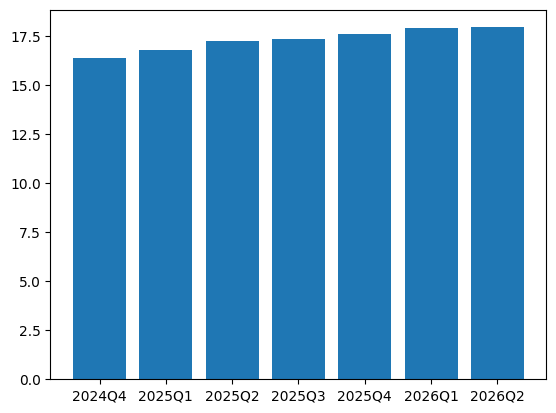

In [129]:
import matplotlib.pyplot as plt

# 1. Préparation des données (une ligne par trimestre, triée par ordre chronologique)
df_plot = (
    df_selection[["trimestre", "VMA_finale"]]
    .drop_duplicates()
    .sort_values("trimestre")
)
df_plot["trimestre_str"] = df_plot["trimestre"].astype(str)

# 2. Le bar plot de base
plt.bar(df_plot["trimestre_str"], df_plot["VMA_finale"])

# 3. Sauvegarde du fichier image
plt.savefig("barplot_vma_base.png")

In [131]:
import pandas as pd

# 1. S'assurer que le trimestre est au format texte pour un affichage propre
df_selection['trimestre_str'] = df_selection['trimestre'].astype(str)

# 2. Création du tableau croisé dynamique (Pivot Table)
tableau_vma = df_selection.pivot_table(
    index='trimestre_str',    # Les lignes du tableau (les trimestres)
    values='VMA',             # La colonne sur laquelle on fait les calculs
    aggfunc=['mean', 'max', 'count'] # Les calculs : Moyenne, Max, et Nombre de courses
)

# 3. Renommer proprement les colonnes pour ton rapport Quarto
tableau_vma.columns = ['VMA_Moyenne', 'VMA_Maximale', 'Nombre_de_Courses']

# Arrondir les résultats à 2 décimales
tableau_vma = tableau_vma.round(2)

# 4. Affichage du tableau croisé dynamique
print("📊 TABLEAU CROISÉ DYNAMIQUE : ÉVOLUTION DE LA VMA")
print("=" * 60)
print(tableau_vma)

📊 TABLEAU CROISÉ DYNAMIQUE : ÉVOLUTION DE LA VMA
               VMA_Moyenne  VMA_Maximale  Nombre_de_Courses
trimestre_str                                              
2024Q4               16.38         16.66                  4
2025Q1               16.80         18.54                  8
2025Q2               17.25         18.43                 11
2025Q3               17.34         18.35                  5
2025Q4               17.62         18.60                  5
2026Q1               17.93         18.78                  8
2026Q2               17.95         17.95                  1
